# Translucid

`translucid` is a library for neural network feature visualization. It provides a transparent and modular way to generate "lucid" visualizations using PyTorch.
<img src="/examples/output.png" width="900">

## Install

You can install `translucid` using pip:

```sh
pip install "git+https://github.com/ssslakter/translucid"
```

## How to use

Here is a simple example showing how to visualize a specific channel in a pre-trained GoogleNet model.

In [ ]:
from translucid.opt import *
from translucid.param.image import *
from torchvision.models import googlenet
import torch

In [ ]:
# Load a pre-trained model
model = googlenet(weights='IMAGENET1K_V1').eval()
if torch.cuda.is_available(): model = model.to('cuda')

In [ ]:
# Define the objective: Maximize activation of channel 139 in the 'inception4a' layer.
obj = channel(layer='inception5a', n_channel=3)

# Create a parameterized image with FFT and Decorrelation.
x = ImageParam.new((1, 3, 256, 512), fft=True, decorr=True)
if torch.cuda.is_available(): x = x.to('cuda')

# Define transforms 
tfms = default_transforms(224) + [to_inception()]

vis = Visualizer(model, obj, x, tfms=tfms)

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:36&lt;00:00... Loss: -7.3032636642456055]</div>

Iteration 0, loss: -0.0
Iteration 100, loss: -1.4929367303848267
Iteration 200, loss: -3.030640125274658
Iteration 300, loss: -4.811450481414795
Iteration 400, loss: -5.048910617828369
Iteration 500, loss: -4.061636924743652
Iteration 600, loss: -4.178513050079346
Iteration 700, loss: -5.030452251434326
Iteration 800, loss: -5.823293209075928
Iteration 900, loss: -5.942066192626953


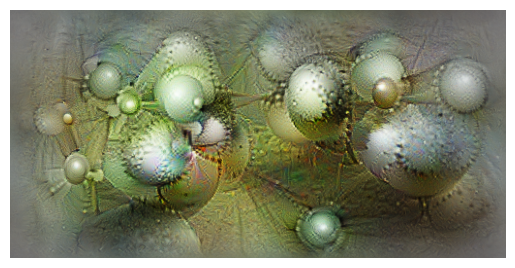

In [ ]:
# Run the visualization
res = vis.visualize(n_iter=1000, param_kwargs={'dp':0.9}, lr=0.01)

# Display the result
_ = res[0].show()

## Key Features

- **Modular Objectives**: Easily combine objectives (e.g., `neuron(Layer, N) + channel(Layer, C)`).
- **Flexible Parameterization**: Support for FFT-based image parameterization and color decorrelation for smoother artifacts.
- **Transparent**: Built with `nbdev`, so the source code is the documentation.
